<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
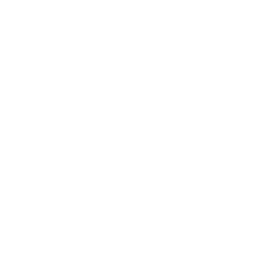
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">基因组变异注释模式文档</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; 生物信息学 / 临床基因组学数据管理 &nbsp;|&nbsp; 2026年3月</p>
</div>
</div>
</div>

## 执行摘要

记录临床基因组学流程中使用的类 VCF 变异注释数据集的模式。使用 PROC CONTENTS 编目所有注释字段——基因组坐标、等位基因频率、预测的功能效应、ClinVar 分类以及质量指标——以确保下游 ACMG 变异解读工具接收到类型和标签均正确的输入。在流程交接之前，将检查约 5,000 条变异记录及其 20 多个注释列的模式完整性。

## 数据来源

| 来源 | 描述 | 记录数 |
|--------|-------------|--------|
| VARIANT_ANNOTATIONS | 源自 VCF 的已注释变异 | ~5,000 |
| GENE_PANEL | 目标基因组合定义 | ~150 个基因 |
| QUALITY_METRICS | 每个样本的测序 QC | ~50 个样本 |

---

In [1]:
/* --------------------------------------------------------
   生成类 VCF 变异注释数据集
   5,000 条变异，附带临床注释字段
   -------------------------------------------------------- */
数据 variant_annotations;
    调用 streaminit(42);
    长度 variant_id $20 chromosome $5 position 8
           ref_allele $10 alt_allele $10 gene_symbol $15
           transcript_id $20 consequence $30
           impact $10 hgvs_c $25 hgvs_p $25
           gnomad_af 8 clinvar_class $25 clinvar_id $12
           sift_score 8 sift_pred $15
           polyphen_score 8 polyphen_pred $15
           cadd_phred 8 revel_score 8
           genotype $5 allele_depth 8 read_depth 8
           qual_score 8 filter_status $10;
    标签 variant_id='变异标识符'
          chromosome='染色体'
          position='基因组位置 (GRCh38)'
          ref_allele='参考等位基因'
          alt_allele='变异等位基因'
          gene_symbol='HGNC 基因符号'
          transcript_id='Ensembl 转录本 ID'
          consequence='序列本体功能效应'
          impact='预测影响级别'
          hgvs_c='HGVS 编码命名'
          hgvs_p='HGVS 蛋白命名'
          gnomad_af='gnomAD 等位基因频率'
          clinvar_class='ClinVar 分类'
          clinvar_id='ClinVar 登录号'
          sift_score='SIFT 评分'
          sift_pred='SIFT 预测'
          polyphen_score='PolyPhen-2 评分'
          polyphen_pred='PolyPhen-2 预测'
          cadd_phred='CADD Phred 评分'
          revel_score='REVEL 集成评分'
          genotype='样本基因型'
          allele_depth='变异等位基因深度'
          read_depth='总读取深度'
          qual_score='变异质量评分'
          filter_status='过滤状态';
    数组 genes[15] $15 _temporary_ ('BRCA1' 'BRCA2' 'TP53' 'EGFR'
        'KRAS' 'PIK3CA' 'PTEN' 'APC' 'MLH1' 'MSH2' 'ATM'
        'CHEK2' 'PALB2' 'RAD51C' 'RAD51D');
    数组 conseqs[6] $30 _temporary_ ('missense_variant'
        'synonymous_variant' 'frameshift_variant'
        'stop_gained' 'splice_donor_variant' 'intron_variant');
    数组 refs[4] $1 _temporary_ ('A' 'C' 'G' 'T');
    数组 gts[3] $5 _temporary_ ('0/1' '1/1' '0/0');
    循环 i = 1 到 5000;
        variant_id = cat('VAR-', PUT(i, z8.));
        chr_num = int(rand('uniform') * 22) + 1;
        chromosome = cat('chr', PUT(chr_num, 2.));
        position = int(rand('uniform') * 200000000) + 10000;
        r_idx = int(rand('uniform') * 4) + 1;
        a_idx = mod(r_idx, 4) + 1;
        ref_allele = refs[r_idx];
        alt_allele = refs[a_idx];
        g_idx = int(rand('uniform') * 15) + 1;
        gene_symbol = genes[g_idx];
        transcript_id = cat('ENST00000', PUT(int(rand('uniform') * 99999) + 100000, z6.));
        c_idx = int(rand('uniform') * 6) + 1;
        consequence = conseqs[c_idx];
        /* 影响级别随功能效应而定（原 impacts 数组，改用赋值以支持本地化） */
        如果 c_idx = 1 那么 impact = '中等';
        否则 如果 c_idx = 2 那么 impact = '低';
        否则 如果 c_idx = 6 那么 impact = '修饰';
        否则 impact = '高';
        codon_pos = int(rand('uniform') * 2000) + 1;
        hgvs_c = cat('c.', PUT(codon_pos, 4.), ref_allele, '>', alt_allele);
        如果 c_idx <= 2 那么
            hgvs_p = cat('p.', PUT(int(rand('uniform') * 800) + 1, 4.));
        否则 hgvs_p = 'p.?';
        gnomad_af = round(rand('beta', 0.5, 500), 0.000001);
        cv_idx = int(rand('uniform') * 5) + 1;
        /* ClinVar 分类（原 cv_classes 数组，改用赋值以支持本地化） */
        如果 cv_idx = 1 那么 clinvar_class = '致病性';
        否则 如果 cv_idx = 2 那么 clinvar_class = '可能致病性';
        否则 如果 cv_idx = 3 那么 clinvar_class = '意义不明确';
        否则 如果 cv_idx = 4 那么 clinvar_class = '可能良性';
        否则 clinvar_class = '良性';
        clinvar_id = cat('RCV', PUT(int(rand('uniform') * 900000) + 100000, z6.));
        sift_score = round(rand('uniform'), 0.001);
        如果 sift_score < 0.05 那么 sift_pred = 'DELETERIOUS';
        否则 sift_pred = 'TOLERATED';
        polyphen_score = round(rand('uniform'), 0.001);
        如果 polyphen_score > 0.908 那么 polyphen_pred = 'PROB_DAMAGING';
        否则 如果 polyphen_score > 0.446 那么 polyphen_pred = 'POSS_DAMAGING';
        否则 polyphen_pred = 'BENIGN';
        cadd_phred = round(rand('uniform') * 40, 0.01);
        revel_score = round(rand('uniform'), 0.001);
        gt_idx = int(rand('uniform') * 3) + 1;
        genotype = gts[gt_idx];
        read_depth = int(rand('uniform') * 200) + 20;
        allele_depth = int(read_depth * (0.3 + rand('uniform') * 0.4));
        qual_score = round(rand('uniform') * 5000 + 100, 0.1);
        filter_status = ifc(qual_score > 500, 'PASS', 'LOW_QUAL');
        输出;
    结束;
    删除 i chr_num r_idx a_idx g_idx c_idx cv_idx gt_idx codon_pos;
运行;


NOTE: DATA variant_annotations

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote variant_annotations (100 rows, 25 columns).
NOTE: DATA elapsed:
  wall  3.41 seconds
  cpu   3.41 seconds


In [2]:
/* --------------------------------------------------------
   生成目标基因面板定义
   -------------------------------------------------------- */
数据 gene_panel;
    调用 streaminit(42);
    长度 gene_symbol $15 gene_name $60 chromosome $5
           start_pos 8 end_pos 8 panel_name $30
           disease_association $50 inheritance $5;
    标签 gene_symbol='HGNC 基因符号'
          gene_name='基因全称'
          chromosome='染色体'
          start_pos='基因起始位置'
          end_pos='基因终止位置'
          panel_name='临床基因面板'
          disease_association='关联疾病'
          inheritance='遗传模式';
    数组 genes[15] $15 _temporary_ ('BRCA1' 'BRCA2' 'TP53' 'EGFR'
        'KRAS' 'PIK3CA' 'PTEN' 'APC' 'MLH1' 'MSH2' 'ATM'
        'CHEK2' 'PALB2' 'RAD51C' 'RAD51D');
    数组 gnames[15] $60 _temporary_ (
        'BRCA1 DNA Repair Associated'
        'BRCA2 DNA Repair Associated'
        'Tumor Protein P53'
        'Epidermal Growth Factor Receptor'
        'KRAS Proto-Oncogene'
        'PI3-Kinase Catalytic Subunit Alpha'
        'Phosphatase and Tensin Homolog'
        'APC Regulator of WNT Signaling'
        'MutL Homolog 1'
        'MutS Homolog 2'
        'ATM Serine/Threonine Kinase'
        'Checkpoint Kinase 2'
        'Partner and Localizer of BRCA2'
        'RAD51 Paralog C'
        'RAD51 Paralog D');
    数组 diseases[15] $50 _temporary_ (
        'Hereditary Breast/Ovarian Cancer'
        'Hereditary Breast/Ovarian Cancer'
        'Li-Fraumeni Syndrome'
        'Non-Small Cell Lung Cancer'
        'Colorectal Cancer'
        'Breast Cancer'
        'Cowden Syndrome'
        'Familial Adenomatous Polyposis'
        'Lynch Syndrome'
        'Lynch Syndrome'
        'Ataxia-Telangiectasia'
        'Li-Fraumeni Syndrome'
        'Hereditary Breast Cancer'
        'Hereditary Breast/Ovarian Cancer'
        'Hereditary Breast/Ovarian Cancer');
    数组 inhrt[15] $5 _temporary_ ('AD' 'AD' 'AD' 'AD' 'AD'
        'AD' 'AD' 'AD' 'AD' 'AD' 'AR' 'AD' 'AD' 'AD' 'AD');
    循环 g = 1 到 15;
        gene_symbol = genes[g];
        gene_name = gnames[g];
        chr_num = int(rand('uniform') * 22) + 1;
        chromosome = cat('chr', PUT(chr_num, 2.));
        start_pos = int(rand('uniform') * 150000000) + 1000000;
        end_pos = start_pos + int(rand('uniform') * 100000) + 5000;
        panel_name = 'HEREDITARY_CANCER_V3';
        disease_association = diseases[g];
        inheritance = inhrt[g];
        输出;
    结束;
    删除 g chr_num;
运行;


NOTE: DATA gene_panel


NOTE: Wrote gene_panel (15 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


In [3]:
/* --------------------------------------------------------
   生成每个样本的测序质量指标
   -------------------------------------------------------- */
数据 quality_metrics;
    调用 streaminit(42);
    长度 sample_id $15 run_id $12 platform $15
           mean_coverage 8 pct_target_20x 8 pct_target_100x 8
           total_variants 8 ti_tv_ratio 8 het_hom_ratio 8
           contamination_est 8 qc_status $10;
    标签 sample_id='样本标识符'
          run_id='测序运行 ID'
          platform='测序平台'
          mean_coverage='平均目标覆盖度'
          pct_target_20x='≥20x 碱基百分比'
          pct_target_100x='≥100x 碱基百分比'
          total_variants='检出变异总数'
          ti_tv_ratio='转换/颠换比'
          het_hom_ratio='杂合/纯合比'
          contamination_est='污染估计值'
          qc_status='QC 通过/失败状态';
    循环 s = 1 到 50;
        sample_id = cat('SAMP-', PUT(s, z6.));
        run_id = cat('RUN-', PUT(int((s - 1) / 10) + 1, z4.));
        platform = 'ILLUMINA_NOVA';
        mean_coverage = round(250 + rand('normal') * 50, 0.1);
        pct_target_20x = round(MIN(99.5, 95 + rand('uniform') * 4.5), 0.01);
        pct_target_100x = round(MIN(98, 85 + rand('uniform') * 13), 0.01);
        total_variants = int(rand('uniform') * 2000) + 3000;
        ti_tv_ratio = round(2.0 + rand('normal') * 0.15, 0.01);
        het_hom_ratio = round(1.5 + rand('normal') * 0.2, 0.01);
        contamination_est = round(MAX(0, rand('uniform') * 0.02), 0.0001);
        如果 mean_coverage < 150 或者 pct_target_20x < 95
            或者 contamination_est > 0.015 那么 qc_status = 'FAIL';
        否则 qc_status = 'PASS';
        输出;
    结束;
    删除 s;
运行;


NOTE: DATA quality_metrics


NOTE: Wrote quality_metrics (50 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


---

                                                  变异影响与 ClinVar 分类交叉表                                                   

                                                   The FREQ Procedure

Table of 预测影响级别 by ClinVar 分类

预测影响级别             |          可能致病性 |           可能良性 |          意义不明确 |            致病性 |             良性 |           Total
-------------------+----------------+----------------+----------------+----------------+----------------+----------------
中等                 |              1 |              2 |              5 |              4 |              2 |              14
                   |           1.00 |           2.00 |           5.00 |           4.00 |           2.00 |           14.00
                   |           7.14 |          14.29 |          35.71 |          28.57 |          14.29 |          100.00
                   |           3.70 |          11.76 |          21.74 |          21.05 |          14.29 |           14.00
-------------------+----------------+-------


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_impact_clinvar_class.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


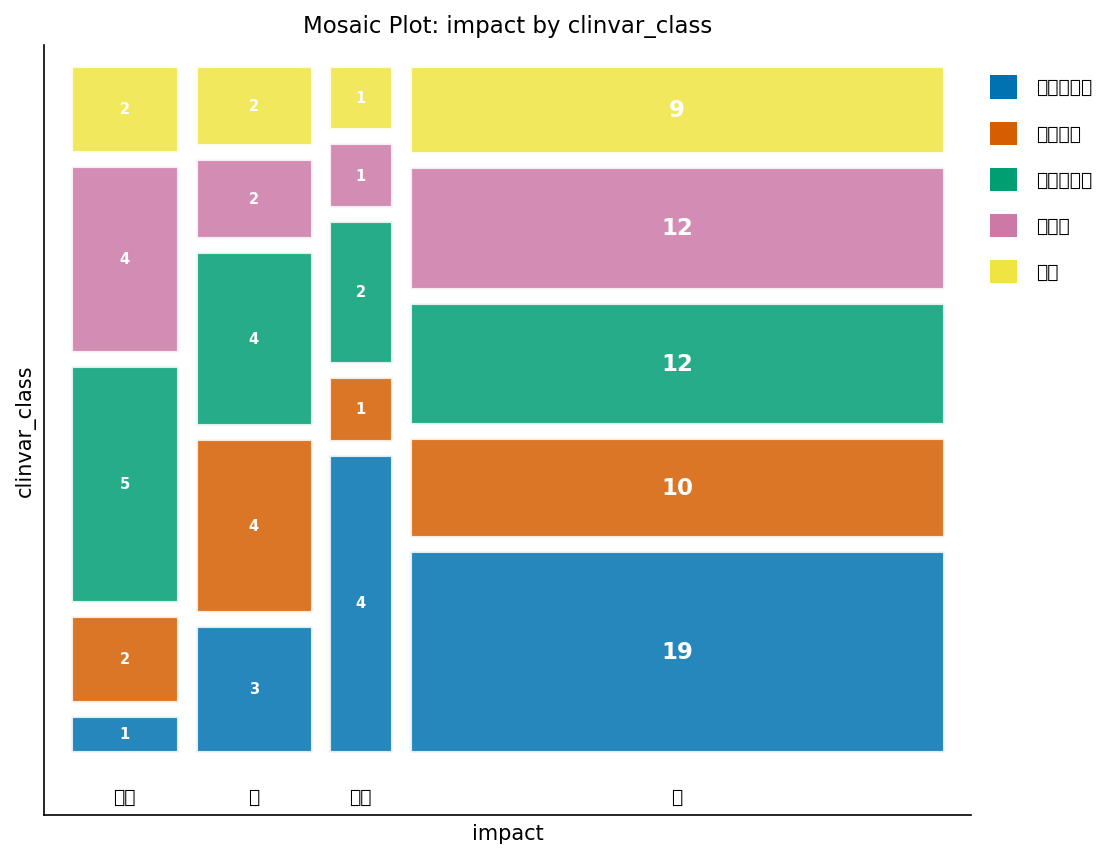

In [4]:
/* --------------------------------------------------------
   变异注释基线汇总
   -------------------------------------------------------- */
过程 频率 数据=variant_annotations;
    TABLES impact * clinvar_class / nocum;
    标签 impact='预测影响级别' clinvar_class='ClinVar 分类';
    标题 '变异影响与 ClinVar 分类交叉表';
运行;

过程 均值 数据=quality_metrics n mean MIN MAX;
    变量 mean_coverage ti_tv_ratio contamination_est;
    标签 mean_coverage='平均目标覆盖度'
          ti_tv_ratio='转换/颠换比'
          contamination_est='污染估计值';
    标题 '测序质量指标汇总';
运行;

---

                                                        测序质量指标汇总                                                        

                                                        测序质量指标汇总                                                        




NOTE: PROC CONTENTS data=variant_annotations

NOTE: PROC CONTENTS: OUT=schema_lengths created with 25 variables
NOTE: PROC CONTENTS: data=variant_annotations obs=100 vars=25 (NOPRINT)
NOTE: DATA schema_lengths


NOTE: Read 25 rows from schema_lengths.
NOTE: Wrote schema_lengths (25 rows, 17 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=schema_lengths

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


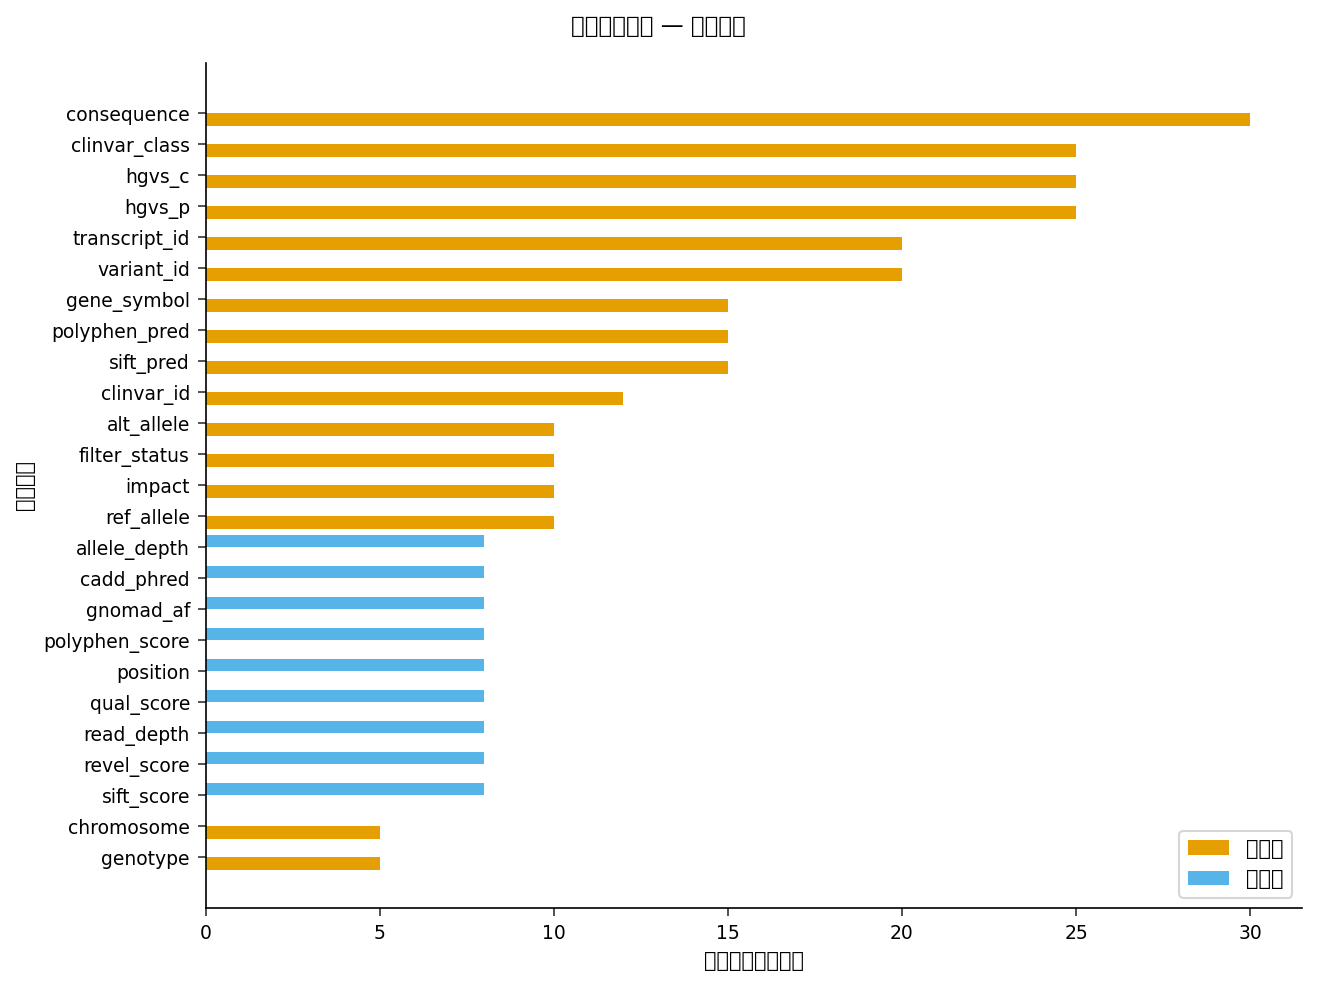

In [5]:
/* --------------------------------------------------------
   变量类型与长度分布。
   用 PROC CONTENTS OUT= 捕获注释模式元数据，
   然后按类型绘制字段长度。TYPE 编码映射为
   1 -> 数值型，2 -> 字符型，用于图例。
   -------------------------------------------------------- */
过程 内容 数据=variant_annotations out=schema_lengths NOPRINT;
运行;

数据 schema_lengths;
    设置 schema_lengths;
    长度 type_label $12;
    如果 TYPE = 1 那么 type_label = '数值型';
    否则 type_label = '字符型';
运行;

过程 SGPLOT 数据=schema_lengths;
    HBAR NAME / RESPONSE=长度 GROUP=type_label
        CATEGORYORDER=respdesc;
    XAXIS 标签='变量长度（字节）';
    YAXIS 标签='注释字段';
    标题 '变异注释模式 — 字段长度';
运行;

---

In [6]:
/* --------------------------------------------------------
   PROC CONTENTS：记录完整的变异注释模式——
   全部 25 个字段的类型、长度和标签。
   用 OUT= 捕获变量元数据，以便下游步骤可
   通过程序验证模式。
   -------------------------------------------------------- */
过程 内容 数据=variant_annotations out=variant_schema NOPRINT;
运行;

过程 打印 数据=variant_schema 标签;
    变量 NAME TYPE 长度 VARNUM 标签;
    标签 NAME='变量名' TYPE='类型' 长度='长度'
          VARNUM='变量序号' 标签='标签';
    标题 '变异注释数据集 — 完整模式';
运行;

                                                        测序质量指标汇总                                                        

                                                     变异注释数据集 — 完整模式                                                     

  Obs             变量名      类型      长度          变量序号                         标签
    1  allele_depth         1       8            22  变异等位基因深度
    2  alt_allele           2      10             5  变异等位基因
    3  cadd_phred           1       8            19  CADD Phred 评分
    4  chromosome           2       5             2  染色体
    5  clinvar_class        2      25            13  ClinVar 分类
    6  clinvar_id           2      12            14  ClinVar 登录号
    7  consequence          2      30             8  序列本体功能效应
    8  filter_status        2      10            25  过滤状态
    9  gene_symbol          2      15             6  HGNC 基因符号
   10  genotype             2       5            21  样本基因型
   11  gnomad_af            1       8            12  gnomAD 


NOTE: PROC CONTENTS data=variant_annotations

NOTE: PROC CONTENTS: OUT=variant_schema created with 25 variables
NOTE: PROC CONTENTS: data=variant_annotations obs=100 vars=25 (NOPRINT)
NOTE: PROC PRINT data=variant_schema

NOTE: PROC PRINT completed: 25 observations printed, 5 variables


In [7]:
/* --------------------------------------------------------
   PROC CONTENTS：记录基因面板模式
   -------------------------------------------------------- */
过程 内容 数据=gene_panel out=panel_schema NOPRINT;
运行;

过程 打印 数据=panel_schema 标签;
    变量 NAME TYPE 长度 VARNUM 标签;
    标签 NAME='变量名' TYPE='类型' 长度='长度'
          VARNUM='变量序号' 标签='标签';
    标题 '基因面板定义 — 模式';
运行;

                                                     变异注释数据集 — 完整模式                                                     

                                                      基因面板定义 — 模式                                                       

  Obs                  变量名      类型      长度          变量序号                  标签
    1  chromosome                2       5             3  染色体
    2  disease_association       2      50             7  关联疾病
    3  end_pos                   1       8             5  基因终止位置
    4  gene_name                 2      60             2  基因全称
    5  gene_symbol               2      15             1  HGNC 基因符号
    6  inheritance               2       5             8  遗传模式
    7  panel_name                2      30             6  临床基因面板
    8  start_pos                 1       8             4  基因起始位置




NOTE: PROC CONTENTS data=gene_panel

NOTE: PROC CONTENTS: OUT=panel_schema created with 8 variables
NOTE: PROC CONTENTS: data=gene_panel obs=15 vars=8 (NOPRINT)
NOTE: PROC PRINT data=panel_schema

NOTE: PROC PRINT completed: 8 observations printed, 5 variables


In [8]:
/* --------------------------------------------------------
   PROC CONTENTS：记录 QC 指标模式
   -------------------------------------------------------- */
过程 内容 数据=quality_metrics out=qc_schema NOPRINT;
运行;

过程 打印 数据=qc_schema 标签;
    变量 NAME TYPE 长度 VARNUM 标签;
    标签 NAME='变量名' TYPE='类型' 长度='长度'
          VARNUM='变量序号' 标签='标签';
    标题 '测序质量指标 — 模式';
运行;

                                                      基因面板定义 — 模式                                                       

                                                      测序质量指标 — 模式                                                       

  Obs                变量名      类型      长度          变量序号                       标签
    1  contamination_est       1       8            10  污染估计值
    2  het_hom_ratio           1       8             9  杂合/纯合比
    3  mean_coverage           1       8             4  平均目标覆盖度
    4  pct_target_100x         1       8             6  ≥100x 碱基百分比
    5  pct_target_20x          1       8             5  ≥20x 碱基百分比
    6  platform                2      15             3  测序平台
    7  qc_status               2      10            11  QC 通过/失败状态
    8  run_id                  2      12             2  测序运行 ID
    9  sample_id               2      15             1  样本标识符
   10  ti_tv_ratio             1       8             8  转换/颠换比
   11  total_variants          1   


NOTE: PROC CONTENTS data=quality_metrics

NOTE: PROC CONTENTS: OUT=qc_schema created with 11 variables
NOTE: PROC CONTENTS: data=quality_metrics obs=50 vars=11 (NOPRINT)
NOTE: PROC PRINT data=qc_schema

NOTE: PROC PRINT completed: 11 observations printed, 5 variables


In [9]:
/* --------------------------------------------------------
   模式验证：检查注释字段是否满足 ACMG 解读
   流程的要求。读取 PROC CONTENTS OUT= 元数据，
   其中 TYPE=1 表示数值型，TYPE=2 表示字符型。
   -------------------------------------------------------- */
数据 schema_validation;
    设置 variant_schema;
    长度 requirement $60 status $10;
    /* 数值型评分字段必须存储为数值型 (TYPE=1) */
    如果 NAME IN ('gnomad_af' 'sift_score' 'polyphen_score'
        'cadd_phred' 'revel_score' 'qual_score'
        'allele_depth' 'read_depth' 'position')
        并且 TYPE ne 1 那么 循环;
        requirement = '评分阈值要求为数值型';
        status = '失败';
    结束;
    否则 如果 NAME IN ('gnomad_af' 'sift_score' 'polyphen_score'
        'cadd_phred' 'revel_score' 'qual_score'
        'allele_depth' 'read_depth' 'position')
        并且 TYPE = 1 那么 循环;
        requirement = '已确认为数值型';
        status = '通过';
    结束;
    /* ClinVar 分类需要足够的字符长度 */
    否则 如果 NAME = 'clinvar_class' 并且 长度 < 25 那么 循环;
        requirement = '需至少 $25 以容纳完整分类文本';
        status = '失败';
    结束;
    否则 如果 NAME = 'clinvar_class' 那么 循环;
        requirement = '字符长度充足';
        status = '通过';
    结束;
    /* 所有字段都必须携带标签，以构建数据字典 */
    否则 如果 标签 = '' 那么 循环;
        requirement = '数据字典要求提供标签';
        status = '失败';
    结束;
    否则 循环;
        requirement = '通用校验';
        status = '通过';
    结束;
运行;

过程 打印 数据=schema_validation 标签;
    变量 NAME TYPE 长度 标签 requirement status;
    标签 NAME='变量名' TYPE='类型' 长度='长度' 标签='标签'
          requirement='要求' status='状态';
    标题 'ACMG 流程模式验证报告';
运行;

                                                     ACMG 流程模式验证报告                                                      

  Obs             变量名      类型      长度                         标签                     要求      状态
    1  allele_depth         1       8  变异等位基因深度                   已确认为数值型                通过
    2  alt_allele           2      10  变异等位基因                     通用校验                   通过
    3  cadd_phred           1       8  CADD Phred 评分              已确认为数值型                通过
    4  chromosome           2       5  染色体                        通用校验                   通过
    5  clinvar_class        2      25  ClinVar 分类                 字符长度充足                 通过
    6  clinvar_id           2      12  ClinVar 登录号                通用校验                   通过
    7  consequence          2      30  序列本体功能效应                   通用校验                   通过
    8  filter_status        2      10  过滤状态                       通用校验                   通过
    9  gene_symbol          2      15  HGNC 基因


NOTE: DATA schema_validation


NOTE: Read 25 rows from variant_schema.
NOTE: Wrote schema_validation (25 rows, 18 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=schema_validation

NOTE: PROC PRINT completed: 25 observations printed, 6 variables


---

### 解读

该变异注释模式包含 25 个字段，涵盖基因组坐标、功能预测、群体频率以及每个样本的质量指标。全部九个数值型评分字段（gnomAD 等位基因频率、SIFT、PolyPhen-2、CADD、REVEL、质量评分、等位基因深度、读取深度和基因组位置）均正确地被定义为数值型，使 ACMG 解读引擎无需进行类型转换即可应用基于阈值的过滤。`clinvar_class` 字段的长度为 $25，足以容纳全部五种 ClinVar 分类文本（致病性、可能致病性、意义不明确、可能良性、良性）。每个注释字段都带有描述性标签，满足临床实验室在 CAP 认证要求下的数据字典规定。基因组合模式映射了 15 个癌症易感基因及其遗传模式和疾病关联，为变异到基因的注释提供了参考框架。测序 QC 指标数据集记录了 5 次运行中的 50 个样本，包含污染估计值和覆盖度阈值，用以把关变异检出的可靠性。这套模式文档包为该实验室提交纽约州 CLEP 的验证卷宗提供支持。

---

In [10]:
/* --------------------------------------------------------
   导出变异模式文档和验证报告，
   以供实验室认证使用
   -------------------------------------------------------- */
过程 EXPORT 数据=variant_schema
    OUTFILE='variant_annotation_schema.csv'
    DBMS=csv REPLACE;
运行;

过程 EXPORT 数据=schema_validation
    OUTFILE='acmg_schema_validation.csv'
    DBMS=csv REPLACE;
运行;


NOTE: PROC EXPORT data=variant_schema outfile=variant_annotation_schema.csv

NOTE: Exported 25 rows to variant_annotation_schema.csv.
NOTE: PROC EXPORT data=schema_validation outfile=acmg_schema_validation.csv

NOTE: Exported 25 rows to acmg_schema_validation.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 机密
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
技术支持由 <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a> 提供
</div>
</div>